<a href="https://colab.research.google.com/github/1vxw/maze_gen/blob/main/mazeGen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Path length:  153
States explored:  106


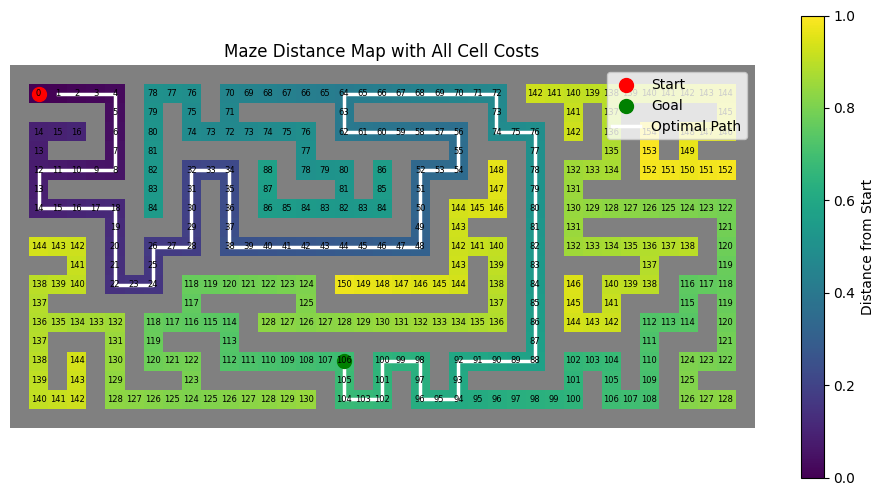

In [75]:
import random
import time
import heapq
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

class Node():
    def __init__(self, s, p, a, g=0, h=0):
        self.state = s
        self.parent = p
        self.action = a
        self.g = g
        self.h = h
        self.f = g + h

class PriorityFrontier():
    def __init__(self):
        self.frontier = []
        self.counter = 0

    def add(self, node, priority):
        heapq.heappush(self.frontier, (priority, self.counter, node))
        self.counter += 1

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("empty frontier")
        return heapq.heappop(self.frontier)[2]

    def contain_state(self, state):
        return any(node.state == state for _, _, node in self.frontier)

class GenMaze():
    MARK = '@'
    EMPTY = ' '
    UP, DOWN, LEFT, RIGHT = 'u','d','l','r'
    WALL = chr(9608)

    def __init__(self, W, H, SEED, x, y):
        self.width = W
        self.height = H
        self.seed = SEED
        self.x = x
        self.y = y
        random.seed(self.seed)
        self.visited = [(x,y)]
        self.maze = [[self.WALL for _ in range(self.height)] for _ in range(self.width)]
        self.maze[x][y] = self.EMPTY
        self.num_explored = 0
        self.start = (self.x, self.y)
        self.explored = set()
        self.solution = None
        self.max_frontier = 0
        self.goal = None
        self.distance_map = [[-1 for _ in range(self.height)] for _ in range(self.width)]

    def getX(self):
      return self.x

    def getY(self):
      return self.y

    def visit(self, x, y):
        self.maze[x][y] = self.EMPTY
        while True:
            unvN = []
            if y > 1 and (x, y-2) not in self.visited:
                unvN.append(self.UP)
            if y < self.height - 2 and (x, y+2) not in self.visited:
                unvN.append(self.DOWN)
            if x > 1 and (x - 2, y) not in self.visited:
                unvN.append(self.LEFT)
            if x < self.width - 2 and (x + 2,y) not in self.visited:
                unvN.append(self.RIGHT)
            if len(unvN) == 0:
                return
            else:
                nextIntersection = random.choice(unvN)
                match nextIntersection:
                    case self.UP:
                        nextX, nextY = x, y - 2
                        self.maze[x][y-1] = self.EMPTY
                    case self.DOWN:
                        nextX, nextY = x, y + 2
                        self.maze[x][y+1] = self.EMPTY
                    case self.LEFT:
                        nextX, nextY = x - 2, y
                        self.maze[x-1][y] = self.EMPTY
                    case self.RIGHT:
                        nextX, nextY = x + 2, y
                        self.maze[x+1][y] = self.EMPTY
                self.visited.append((nextX, nextY))
                self.visit(nextX, nextY)

    def neighbors(self, state):
        curr_x, curr_y = state
        candidates = []
        if curr_y > 0 and self.maze[curr_x][curr_y - 1] != self.WALL:
            candidates.append((self.UP, (curr_x, curr_y - 1)))
        if curr_y < self.height - 1 and self.maze[curr_x][curr_y + 1] != self.WALL:
            candidates.append((self.DOWN, (curr_x, curr_y + 1)))
        if curr_x > 0 and self.maze[curr_x - 1][curr_y] != self.WALL:
            candidates.append((self.LEFT, (curr_x - 1, curr_y)))
        if curr_x < self.width - 1 and self.maze[curr_x + 1][curr_y] != self.WALL:
            candidates.append((self.RIGHT, (curr_x + 1, curr_y)))
        return candidates

    def heuristic(self, state):
        x1, y1 = state
        x2, y2 = self.goal
        return abs(x1 - x2) + abs(y1 - y2)

    def random_goal(self):
        self.goal = random.choice([cell for cell in self.visited if cell != self.start])

    def compute_distance_map(self):
        queue = deque()
        visited = set()
        sx, sy = self.start
        queue.append((sx, sy, 0))
        visited.add((sx, sy))
        self.distance_map[sx][sy] = 0
        while queue:
            x, y, dist = queue.popleft()
            for _, (nx, ny) in self.neighbors((x, y)):
                if (nx, ny) not in visited and self.maze[nx][ny] == self.EMPTY:
                    visited.add((nx, ny))
                    self.distance_map[nx][ny] = dist + 1
                    queue.append((nx, ny, dist + 1))

    def solve(self):
        self.num_explored = 0
        self.explored = set()
        self.max_frontier = 0
        start_node = Node(self.start, None, None, g=0, h=self.heuristic(self.start))
        frontier = PriorityFrontier()
        frontier.add(start_node, start_node.f)
        while True:
            if frontier.empty():
                raise Exception("No solution")
            node = frontier.remove()
            self.num_explored += 1
            self.max_frontier = max(self.max_frontier, len(frontier.frontier))
            self.explored.add(node.state)
            if node.state == self.goal:
                actions = []
                cells = []
                while node.parent is not None:
                    actions.append(node.action)
                    cells.append(node.state)
                    node = node.parent
                actions.reverse()
                cells.reverse()
                self.solution = (actions, cells)
                return
            for action, state in self.neighbors(node.state):
                if state not in self.explored and not frontier.contain_state(state):
                    g = node.g + 1
                    h = self.heuristic(state)
                    child = Node(state, node, action, g, h)
                    frontier.add(child, child.f)

    def visualize(self):
        dist_array = np.full((self.height, self.width), -1.0)
        for x in range(self.width):
            for y in range(self.height):
                if self.maze[x][y] != self.WALL:
                    dist_array[y, x] = self.distance_map[x][y]

        plt.figure(figsize=(12, 6))
        cmap = plt.cm.viridis
        cmap.set_under(color='gray')
        plt.imshow(dist_array, cmap=cmap, origin='upper', vmin=0)

        sx, sy = self.start
        gx, gy = self.goal
        plt.scatter([sx], [sy], color='red', s=100, label='Start', zorder=3)
        plt.scatter([gx], [gy], color='green', s=100, label='Goal', zorder=3)

        if self.solution:
            _, cells = self.solution
            path_x = [c[0] for c in cells]
            path_y = [c[1] for c in cells]
            plt.plot(path_x, path_y, color='white', linewidth=2.5, label='Optimal Path', zorder=2)

        for x in range(self.width):
            for y in range(self.height):
                if self.maze[x][y] != self.WALL:
                    plt.text(x, y, str(self.distance_map[x][y]),
                             color='black', ha='center', va='center', fontsize=6, zorder=4)

        plt.colorbar(label="Distance from Start")
        plt.legend(loc='upper right')
        plt.title("Maze Distance Map with All Cell Costs")
        plt.axis('off')
        plt.show()

width, height = 39, 19
start_x, start_y = 1, 1
seed = 41

maze = GenMaze(width, height, seed, x=start_x, y=start_y)
maze.visit(maze.getX(), maze.getY())
maze.random_goal()
maze.compute_distance_map()
maze.solve()
print("Optimal Path length: ",maze.num_explored)
actions, cells = maze.solution

print("States explored: ",len(actions))
maze.visualize()